# Phase 6 — Quantitative Performance Comparison

Unified comparison of all three detectors, evaluated through a shared
evaluation harness (`src/evaluate.py`) so metrics are computed
identically across models -- unlike each model's individual
`performance_report.json`, which used each framework's own internal
validator with different definitions/measurement methods.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

with open(PROJECT_ROOT / "results" / "comparison_tables" / "full_comparison.json") as f:
    comparison = json.load(f)

df = pd.DataFrame(comparison).T
df

,precision,recall,f1_score,mean_iou,mean_dice,mAP50,mAP50_95,FPS,GPU_memory_MB,parameters,GFLOPs,model_size_MB,training_time_hours,inference_time_ms
YOLOv8n,0.9266,0.9044,0.9154,0.8238,0.9034,0.9201,0.6061,22.71,25.77,3011823.0,8.20,5.96,10.000000,44.03
RT-DETR-L,0.9400,0.9625,0.9511,0.8309,0.9076,0.9703,0.6518,14.71,243.98,32816351.0,109.91,251.47,37.000000,67.98
DEIMv2-Nano (DINO sub.),0.9133,0.9352,0.9241,0.8297,0.9069,0.9636,0.6552,20.79,91.67,3556617.0,NaN,13.75,1.386663,48.10


## Detection metrics

In [2]:
detection_cols = ["precision", "recall", "f1_score", "mean_iou", "mean_dice", "mAP50", "mAP50_95"]
detection_df = df[detection_cols].astype(float)
detection_df.style.background_gradient(cmap="Greens", axis=0).format("{:.3f}")

,precision,recall,f1_score,mean_iou,mean_dice,mAP50,mAP50_95
YOLOv8n,0.927,0.904,0.915,0.824,0.903,0.920,0.606
RT-DETR-L,0.940,0.963,0.951,0.831,0.908,0.970,0.652
DEIMv2-Nano (DINO sub.),0.913,0.935,0.924,0.830,0.907,0.964,0.655


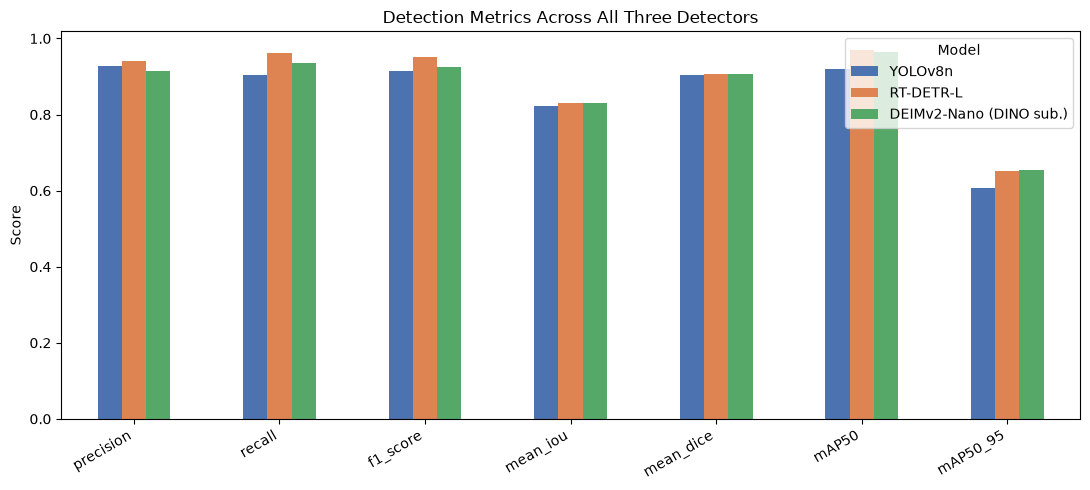

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
detection_df.T.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Detection Metrics Across All Three Detectors")
ax.set_ylabel("Score")
ax.legend(title="Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "detection_metrics_comparison.png", dpi=150)
plt.show()

## Computational metrics

In [4]:
computational_cols = ["FPS", "GPU_memory_MB", "parameters", "GFLOPs", "model_size_MB", "training_time_hours"]
computational_df = df[computational_cols]
computational_df

,FPS,GPU_memory_MB,parameters,GFLOPs,model_size_MB,training_time_hours
YOLOv8n,22.71,25.77,3011823.0,8.20,5.96,10.000000
RT-DETR-L,14.71,243.98,32816351.0,109.91,251.47,37.000000
DEIMv2-Nano (DINO sub.),20.79,91.67,3556617.0,NaN,13.75,1.386663


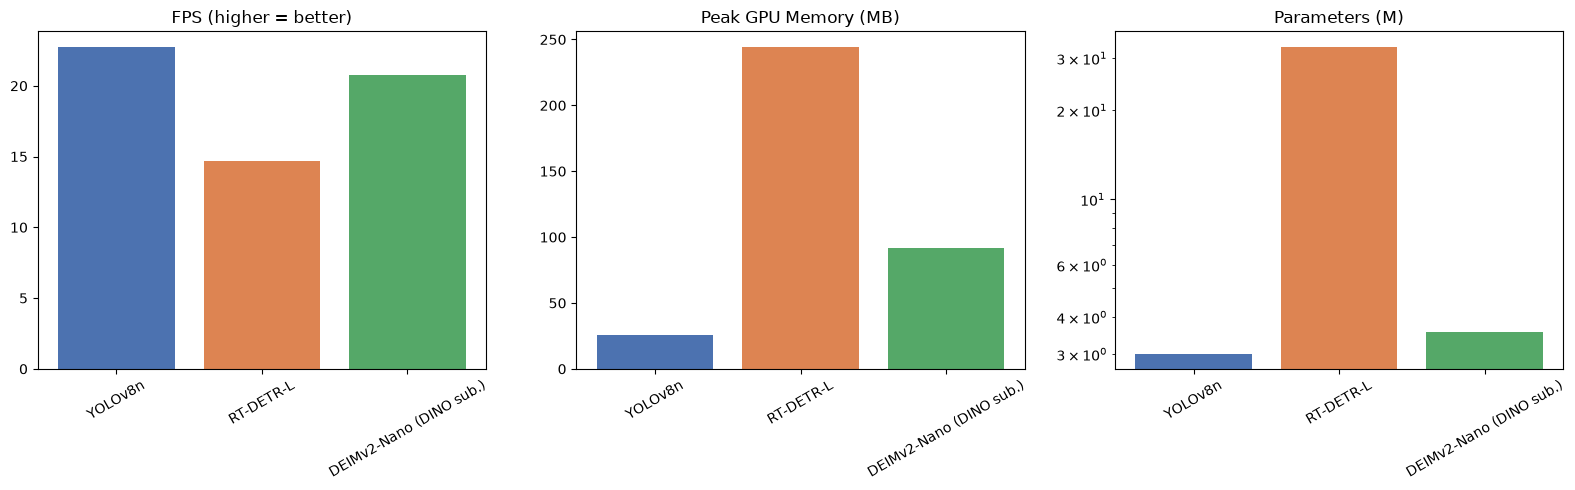

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = df.index.tolist()
colors = ["#4C72B0", "#DD8452", "#55A868"]

axes[0].bar(models, df["FPS"].astype(float), color=colors)
axes[0].set_title("FPS (higher = better)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(models, df["GPU_memory_MB"].astype(float), color=colors)
axes[1].set_title("Peak GPU Memory (MB)")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(models, df["parameters"].astype(float) / 1e6, color=colors)
axes[2].set_title("Parameters (M)")
axes[2].set_yscale("log")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "computational_metrics_comparison.png", dpi=150)
plt.show()

## Accuracy vs. efficiency trade-off

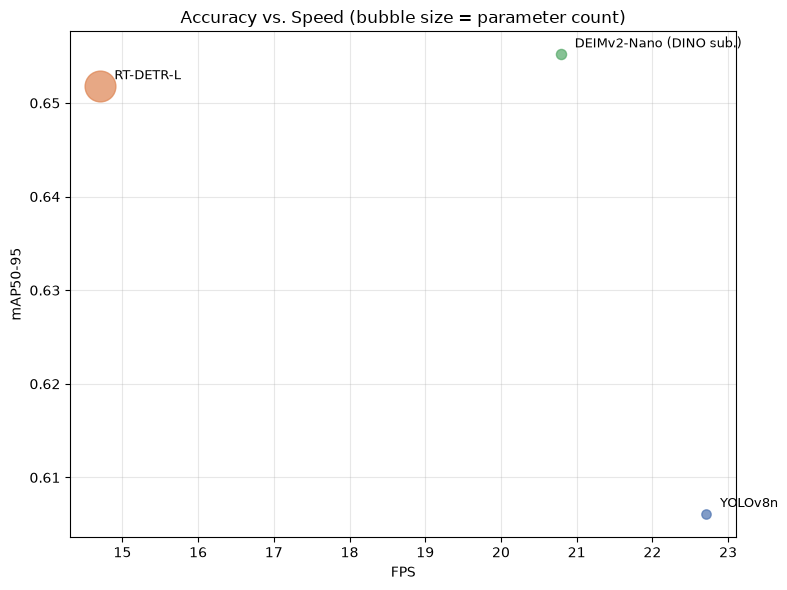

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, model in enumerate(models):
    ax.scatter(df.loc[model, "FPS"], df.loc[model, "mAP50_95"],
               s=df.loc[model, "parameters"] / 1e6 * 15,  # bubble size = params
               color=colors[i], alpha=0.7, label=model)
    ax.annotate(model, (df.loc[model, "FPS"], df.loc[model, "mAP50_95"]),
                textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_xlabel("FPS")
ax.set_ylabel("mAP50-95")
ax.set_title("Accuracy vs. Speed (bubble size = parameter count)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "accuracy_speed_tradeoff.png", dpi=150)
plt.show()

## Notes on methodology

- All detection metrics (precision, recall, F1, mean IoU, Dice, mAP)
  were computed via a single shared evaluation script
  (`src/evaluate.py`) applying identical greedy IoU-matching
  (conf=0.25, IoU=0.5) and `torchmetrics` mAP computation to all three
  models' raw predictions -- not each framework's own built-in
  validator, which use different internal conventions.
- FPS and GPU memory were measured freshly via single-image inference
  loops for all three models under this evaluation script, for a fair
  comparison (earlier per-phase reports used each framework's own,
  differently-optimized inference paths).
- GFLOPs for DEIMv2-Nano is not available -- no integrated FLOP
  counter exists for HuggingFace transformer models in this pipeline
  (Ultralytics provides this natively for YOLOv8/RT-DETR).
- Training time for RT-DETR-L is not meaningfully reportable as a
  single number, since training was resumed across multiple sessions
  interrupted by system restarts.

## Summary

- **RT-DETR-L**: highest recall (0.963), F1 (0.951), and mAP50 (0.970)
  -- but at 11x the parameters, ~9x the GPU memory, and ~1.5x slower
  inference than DEIMv2-Nano.
- **DEIMv2-Nano** (DINO substitute): best mAP50-95 (0.655) of all
  three, with parameter count comparable to YOLOv8n -- suggesting
  DINO's denoising-training and anchor-refinement mechanisms provide
  real accuracy benefit without RT-DETR-scale computational cost.
- **YOLOv8n**: fastest inference and lowest GPU memory by a wide
  margin, at a real cost in recall and mAP50-95 -- the clearest choice
  for genuinely resource-constrained real-time deployment.
- This sets up the central trade-off to explore in Phase 10
  (Scientific Discussion): no single detector dominates on every
  metric, and the "right" choice depends on deployment constraints.